# IT Support Dashboard - Supporting Notebook 3

This series of notebooks contains supporting documentation to the full report. Here, we provide quality checks for the full dataset, confirm whether the English-only sample is representitive of the full population available, and conduct text analytics.

## Text Normalisation & Thematic Recurrence Detection

Notebook 3 provides the text analytics for the cleaned English subset. Here, we will apply Natural Language Processing (NLP) techniques to analyse ticket text by quantifying how frequently similar issues recur across the dataset. By representing text as numerical vectors using Term Frequency–Inverse Document Frequency (TF-IDF) and comparing them with cosine similarity, we can measure thematic overlap between tickets.

- Term Frequency (TF): how often a word appears in a ticket.

- Inverse Document Frequency (IDF): how rare that word is across all tickets.

Words common across tickets (e.g. error, crash, security) receive lower weights, while unique or context-specific terms (error403, license timeout) receive higher weights. Cosine similarity then measures how close two text vectors are in semantic space (1 = identical, 0 = unrelated). Together, these techniques reveal repeated problem statements and recurring support patterns which are crucial for identifying automation or knowledge-base opportunities.

### Importing

First, the required packages for this process were imported, the necessary folders were created using the config file, and the clean dataset was read.

In [16]:
# Importing essential packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, gaussian_kde
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Add parent directory (project root) to sys.path
project_root = Path(r"C:\Users\David\Desktop\Python_Files\IT-Support-Ticket-Analysis")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from config import Config

Config.ensure_directories()

# Reading the initial dataset as a DataFrame: df
df = pd.read_parquet(Config.ENGLISH_PARQUET_PATH, engine="pyarrow")

display(df)

[Config] Verified project directory structure under C:\Users\David\Desktop\Python_Files\IT-Support-Ticket-Analysis


,Subject,Body,Answer,Type,Queue,Priority,Language,Version,Tag_1,Tag_2,Tag_3,Tag_4,Tag_5,Tag_6,Tag_7,Tag_8
0,Account Disruption,"Dear Customer Support Team, I am writing to re...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,High,EN,51,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
1,Query About Smart Home System Integration Feat...,"Dear Customer Support Team, I hope this messag...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,Medium,EN,51,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
2,Inquiry Regarding Invoice Details,"Dear Customer Support Team, I hope this messag...",We appreciate you reaching out with your billi...,Request,Billing and Payments,Low,EN,51,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
3,Question About Marketing Agency Software Compa...,"Dear Support Team, I hope this message reaches...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,Medium,EN,51,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN
4,Feature Query,"Dear Customer Support, I hope this message rea...",Thank you for your inquiry. Please specify whi...,Request,Technical Support,High,EN,51,Feature,Product,Documentation,Feedback,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13724,Problem with Billing Adjustment,An unexpected billing discrepancy has been not...,We apologize for the billing discrepancy in th...,Incident,Billing and Payments,High,EN,400,Billing,Payment,Performance,Bug,NaN,NaN,NaN,NaN
13725,Urgent: Incident Involving Data Breach in Medi...,"A data breach has occurred, which might be rel...","Dear [Name], we acknowledge the urgency of the...",Problem,Product Support,Medium,EN,400,Security,Incident,Bug,Performance,NaN,NaN,NaN,NaN
13726,Performance Problem with Data Analytics Tool,The data analytics tool experiences sluggish p...,We are addressing the performance issue with t...,Incident,Technical Support,High,EN,400,Performance,IT,Tech Support,NaN,NaN,NaN,NaN,NaN
13727,Update Request for SaaS Platform Integration F...,Requesting an update on the integration featur...,Received your request for updates on the integ...,Change,IT Support,High,EN,400,Feature,IT,Tech Support,NaN,NaN,NaN,NaN,NaN


### Boosting signal, reducing noise

First, we combined the subject, body, and answer fields into one large text to create a stronger signal of what the key issues the customer was experiencing.

In [17]:
# Creating a lemmatising text dataframe
lemmatised_text_df = df[
    ["Subject", "Body", "Answer", "Type", "Queue", "Priority", "Language", "Version"]
].copy()

# Combining text to boost signal
lemmatised_text_df["Combined Text"] = (
    lemmatised_text_df["Subject"]
    + " "
    + lemmatised_text_df["Body"]
    + " "
    + lemmatised_text_df["Answer"]
)

# Drop redundant text columns
lemmatised_text_df.drop(columns=["Subject", "Body", "Answer"], axis=1, inplace=True)

# Show lemmatised dataframe
display(lemmatised_text_df)

,Type,Queue,Priority,Language,Version,Combined Text
0,Incident,Technical Support,High,EN,51,"Account Disruption Dear Customer Support Team,..."
1,Request,Returns and Exchanges,Medium,EN,51,Query About Smart Home System Integration Feat...
2,Request,Billing and Payments,Low,EN,51,Inquiry Regarding Invoice Details Dear Custome...
3,Problem,Sales and Pre-Sales,Medium,EN,51,Question About Marketing Agency Software Compa...
4,Request,Technical Support,High,EN,51,"Feature Query Dear Customer Support, I hope th..."
...,...,...,...,...,...,...
13724,Incident,Billing and Payments,High,EN,400,Problem with Billing Adjustment An unexpected ...
13725,Problem,Product Support,Medium,EN,400,Urgent: Incident Involving Data Breach in Medi...
13726,Incident,Technical Support,High,EN,400,Performance Problem with Data Analytics Tool T...
13727,Change,IT Support,High,EN,400,Update Request for SaaS Platform Integration F...


The combined text was then normalised (lemmatised) to reduce redundant word forms, ensuring that morphologically similar words (e.g. running, ran, runs) were treated as one concept (run).

In [18]:
# Lemmatization using spaCy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])


# Function to lemmatize text
def lemmatise_text(text: str) -> str:
    """Return lemmatized string of alphabetic, non-stopword tokens."""
    doc = nlp(text)
    return " ".join(
        token.lemma_
        for token in doc
        if not token.is_stop and token.is_alpha and len(token) > 2
    )


# Apply lemmatization to each record
print("Lemmatising the text (~3-4 mins)...")
lemmatised_text_df["Lemmatised Text"] = lemmatised_text_df["Combined Text"].apply(
    lemmatise_text
)

# Measuring the token reduction from lemmatising the text
lemmatised_text_df["Tokens Before"] = lemmatised_text_df["Combined Text"].str.len()
lemmatised_text_df["Tokens After"] = lemmatised_text_df["Lemmatised Text"].str.len()

# Show changes at a glance
display(
    lemmatised_text_df[
        ["Combined Text", "Lemmatised Text", "Tokens Before", "Tokens After"]
    ]
)

Lemmatising the text (~3-4 mins)...


,Combined Text,Lemmatised Text,Tokens Before,Tokens After
0,"Account Disruption Dear Customer Support Team,...",Account Disruption Dear Customer Support Team ...,1059,674
1,Query About Smart Home System Integration Feat...,query Smart Home System Integration feature De...,1084,787
2,Inquiry Regarding Invoice Details Dear Custome...,inquiry Invoice detail Dear Customer Support T...,1173,770
3,Question About Marketing Agency Software Compa...,question Marketing Agency Software Compatibili...,1000,670
4,"Feature Query Dear Customer Support, I hope th...",feature Query Dear Customer Support hope messa...,804,504
...,...,...,...,...
13724,Problem with Billing Adjustment An unexpected ...,problem Billing Adjustment unexpected billing ...,471,302
13725,Urgent: Incident Involving Data Breach in Medi...,Urgent Incident Involving Data Breach Medical ...,763,467
13726,Performance Problem with Data Analytics Tool T...,Performance Problem Data Analytics Tool data a...,391,274
13727,Update Request for SaaS Platform Integration F...,update request SaaS Platform Integration featu...,611,422


### Similarity comparison

Now that the vocabulary represented concepts rather than word forms, TF-IDF will treat more of the text as related features, defragmenting the signal across the vector space. This improves semantic density, clustering stability, and feature importance estimation. However, over-normalisation could accidentally merge distinct meanings, which would degrade model quality.

For this reason, we empirically verified if the transformation improved semantic grouping while preserving corpus structure, using two paired tests:

- The Cosine similarity test for how close the tickets were to each other
- The Kolmogorov–Smirnov (KS) test for determining if the similarity distribution shifted after lemmatization

This allowed us to check if this process tightened the grouping of genuinely similar tickets, without warping the geometry of the overall dataset.

### Cosine similarity test

First, we calculated the cosine similarity of each ticket to its nearest neighbour in the vector space, before and after lemmatization. This measures how closely tickets cluster together based on their text content.

In [19]:
# Then, we measured total token reduction from lemmatisation
token_before = lemmatised_text_df["Combined Text"].str.split().str.len().sum()
token_after = lemmatised_text_df["Lemmatised Text"].str.split().str.len().sum()
reduction_pct = 1 - token_after / token_before


# Max similarity function to compute each row's max cosine similarity (excluding self)
def max_similarity(tfidf_mat):
    """Compute each row's max cosine similarity (excluding self)."""
    cos = cosine_similarity(tfidf_mat, dense_output=False)
    vals = []
    for i in range(cos.shape[0]):
        row = cos[i].toarray().ravel()
        row[i] = 0
        vals.append(row.max())
    return np.array(vals)


print("Vectorising text in progress (20-40s)...")

# max_features has been set to 5000 to limit dimensionality, improving performance, and reducing memory usage
vec_raw = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))
vec_lemma = TfidfVectorizer(stop_words="english", max_features=5000, ngram_range=(1, 2))

# TF-IDF vectorisation on lemmatised text
tfidf_matrix = vec_lemma.fit_transform(lemmatised_text_df["Lemmatised Text"])

# Exporting the TF-IDF matrix as a parquet file for later use in clustering and topic modelling
tfidf_matrix_df = pd.DataFrame(
    tfidf_matrix.toarray(), columns=vec_lemma.get_feature_names_out()
)
tfidf_matrix_df.to_parquet(
    Config.TFIDF_MATRIX_PATH, engine="pyarrow", compression="snappy"
)

# Finding the max similarity between the 2 distributions
raw_sim = max_similarity(vec_raw.fit_transform(lemmatised_text_df["Combined Text"]))
lemma_sim = max_similarity(tfidf_matrix)

# Adding the max similarity values to the dataframe for later analysis
lemmatised_text_df["Raw Max Similarity"] = raw_sim
lemmatised_text_df["Lemma Max Similarity"] = lemma_sim

# Saving lemmatised text, tokens, and max similarity comparison
lemmatised_text_df[
    [
        "Combined Text",
        "Lemmatised Text",
        "Tokens Before",
        "Tokens After",
        "Raw Max Similarity",
        "Lemma Max Similarity",
    ]
].to_csv(Config.LEMMATISED_PATH, index=False, encoding="latin-1")

# Displaying the lemmatised text, token counts, and max similarity comparison
display(
    lemmatised_text_df[
        [
            "Combined Text",
            "Lemmatised Text",
            "Tokens Before",
            "Tokens After",
            "Raw Max Similarity",
            "Lemma Max Similarity",
        ]
    ]
)

Vectorising text in progress (20-40s)...


,Combined Text,Lemmatised Text,Tokens Before,Tokens After,Raw Max Similarity,Lemma Max Similarity
0,"Account Disruption Dear Customer Support Team,...",Account Disruption Dear Customer Support Team ...,1059,674,0.775342,0.796301
1,Query About Smart Home System Integration Feat...,query Smart Home System Integration feature De...,1084,787,0.655095,0.613764
2,Inquiry Regarding Invoice Details Dear Custome...,inquiry Invoice detail Dear Customer Support T...,1173,770,0.873897,0.906186
3,Question About Marketing Agency Software Compa...,question Marketing Agency Software Compatibili...,1000,670,0.833926,0.834966
4,"Feature Query Dear Customer Support, I hope th...",feature Query Dear Customer Support hope messa...,804,504,0.408067,0.400885
...,...,...,...,...,...,...
13724,Problem with Billing Adjustment An unexpected ...,problem Billing Adjustment unexpected billing ...,471,302,0.896822,0.927772
13725,Urgent: Incident Involving Data Breach in Medi...,Urgent Incident Involving Data Breach Medical ...,763,467,0.909368,0.938253
13726,Performance Problem with Data Analytics Tool T...,Performance Problem Data Analytics Tool data a...,391,274,0.717657,0.596063
13727,Update Request for SaaS Platform Integration F...,update request SaaS Platform Integration featu...,611,422,0.874209,0.885953


### Kolmogorov–Smirnov (KS) test

Next, we applied the KS test to compare the distributions of maximum cosine similarities before and after lemmatization. This non-parametric test checks if the two samples come from the same distribution, indicating whether lemmatization significantly altered the overall similarity structure of the dataset.

In [20]:
# KS test to compare the distributions of max similarities before and after lemmatisation
ks_result = ks_2samp(raw_sim, lemma_sim)

# Lemmatisation impact summary table
token_reduction_pct = f"{float(reduction_pct) * 100:.2f}%"
raw_sim_mean_pct = f"{(raw_sim >= 0.85).mean() * 100:.2f}%"
lemma_sim_mean_pct = f"{(lemma_sim >= 0.85).mean() * 100:.2f}%"


summary_rows = [
    ("Token reduction", token_reduction_pct),
    ("KS statistic", ks_result.statistic),
    ("KS p-value", ks_result.pvalue),
    ("Mean max similarity (before)", raw_sim.mean()),
    ("Mean max similarity (after)", lemma_sim.mean()),
    ("Median max similarity (before)", np.median(raw_sim)),
    ("Median max similarity (after)", np.median(lemma_sim)),
    ("Share with similarity ≥ 0.85 (before)", raw_sim_mean_pct),
    ("Share with similarity ≥ 0.85 (after)", lemma_sim_mean_pct),
]

summary = pd.DataFrame(summary_rows, columns=["Metric", "Value"])

# Saving the summary table to CSV
summary.to_csv(Config.LEMMA_SUMMARY_PATH, index=False, encoding="utf-8")

# Formatting the summary table for better readability
summary_formatted = summary.copy()

summary_formatted.loc[1, "Value"] = f"{summary_formatted.loc[1, 'Value']:.2e}"
summary_formatted.loc[2, "Value"] = f"{summary_formatted.loc[2, 'Value']:.2e}"
summary_formatted.loc[3, "Value"] = f"{summary_formatted.loc[3, 'Value']:.3f}"
summary_formatted.loc[4, "Value"] = f"{summary_formatted.loc[4, 'Value']:.3f}"
summary_formatted.loc[5, "Value"] = f"{summary_formatted.loc[5, 'Value']:.3f}"
summary_formatted.loc[6, "Value"] = f"{summary_formatted.loc[6, 'Value']:.3f}"

print("The Lemmetization impact summary table:")
display(summary_formatted)

The Lemmetization impact summary table:


,Metric,Value
0,Token reduction,45.08%
1,KS statistic,1.97e-02
2,KS p-value,9.38e-03
3,Mean max similarity (before),0.733
4,Mean max similarity (after),0.733
5,Median max similarity (before),0.802
6,Median max similarity (after),0.805
7,Share with similarity ≥ 0.85 (before),36.13%
8,Share with similarity ≥ 0.85 (after),37.81%


#### Similarity testing insights

Lemmatisation significantly reduced the total sum of tokens within all tickets, removing 45.08% of redundant characters. This indicated that the combined text had heavy stopword removal, normalization of variants, and vocabulary consolidation. This means that the TF-IDF space will become much less sparse, which is good for clustering.

The mean value did not change from before (0.733) to after (0.733), showing that the overall similarity structure of the dataset remained stable.

The median value slightly increased from before (0.802) to after (0.805), suggesting that normalization slightly tightened semantic similarity between documents.

We chose to test the right-tail similarity at the ≥0.85 threshold, because these results represented strong semantic overlap in TF-IDF space. So the threshold isolated high-confidence semantic matches. This value increased from 36.13% (before) to 37.81% (after), indicating that the proportion of very similar document pairs increased slightly but consistently. This meant that lemmatization had successfully pulled near-duplicate tickets closer together in vector space, improving downstream clustering.

The KS stat produced was extremely small at 0.0197, meaning the similarity distribution changed only slightly. So lemmatization did not distort the corpus geometry, proving that the intra-cluster cohesion improved without collapsing distinct topics. This should lead to better cluster separation, more stable centroids, and cleaner topic labels.

### KDE plot

To help with the comparrison, we produced a KDE plot of the text before and after lemmatization.


KDE plot of similarity distributions:


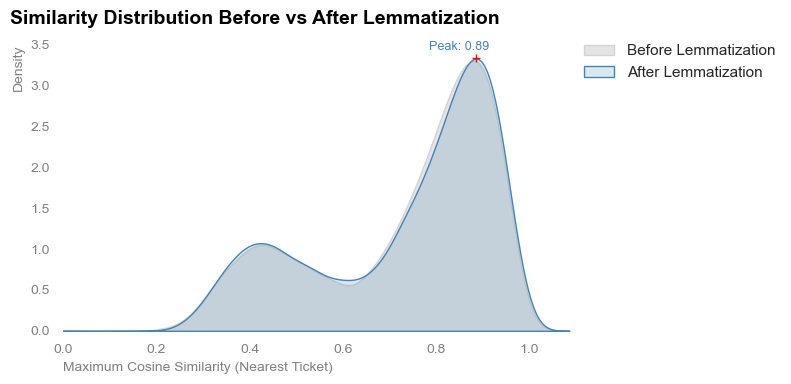

In [21]:
# Lemmatization impact density plot
sns.set_theme(style="white")

# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(8, 4))

sns.kdeplot(
    raw_sim, label="Before Lemmatization", color="lightgrey", fill=True, alpha=0.6
)
sns.kdeplot(
    lemma_sim, label="After Lemmatization", color="steelblue", fill=True, alpha=0.2
)

# Add a marker at the highest density point of the lemma_sim KDE
kde = gaussian_kde(lemma_sim)
x_vals = np.linspace(lemma_sim.min(), lemma_sim.max(), 1000)
y_vals = kde(x_vals)
peak_x = x_vals[np.argmax(y_vals)]
peak_y = y_vals.max()

ax.annotate(
    f"Peak: {peak_x:.2f}",
    xy=(peak_x, peak_y),
    xytext=(peak_x - 0.1, peak_y + 0.1),
    fontsize=9,
    color="steelblue",
)
ax.plot(peak_x, peak_y, "+", color="red", markersize=6)

# Clean borders: remove top/right spines
sns.despine(left=True, top=True, bottom=True, right=True)

# Set labels and markers to grey for subtlety
ax.set_xlabel("Maximum Cosine Similarity (Nearest Ticket)", color="grey")
ax.set_ylabel("Density", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_size(10)
ax.xaxis.label.set_size(10)
ax.tick_params(labelsize=10)

# Remove horizontal padding so the line starts at the y-axis
ax.set_xlim(lemma_sim.min())

# Setting the axis allignment and position to the left for better aesthetics
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Title parameters
ax.set_title(
    "Similarity Distribution Before vs After Lemmatization",
    fontsize=14,
    fontweight="bold",
    color="black",
    pad=15,
    loc="left",
    x=-0.1,
)

# Move legend to the right side of the plot
ax.legend(bbox_to_anchor=(0.95, 1.05), loc="upper left", edgecolor="white")

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(Config.KDE_PATH, dpi=300, bbox_inches="tight")
print("\nKDE plot of similarity distributions:")
plt.show()

The KDE peak was at 0.89, which is a very high similarity value, indicating that many tickets had very similar text content. This suggests that there are many recurring issues or common themes across the support tickets, which could be valuable for identifying areas for automation or knowledge-base development.

### Quantifying the right-tail

The KS test showed that overall similarity distributions changed only slightly, and the KDE plot showed where those distributions sit visually. To make that shift actionable, we then plotted the proportion of tickets above high-similarity thresholds (0.85, 0.90, 0.95). We delibrately chose to start at 0.85, before the peak at 0.89, to capture the growth of near-duplicate tickets that are most relevant for standardisation and automation.

This lineplot turns a visual pattern into measurable recurrence rates, showing how strongly lemmatization increased the share of near-duplicate tickets that are most relevant for standardisation and automation.


Right-tail similarity proportions:


,Threshold,Proportion
0,0.85,0.378
1,0.90,0.206
2,0.95,0.049



Proportion of tickets exceeding high-similarity thresholds:


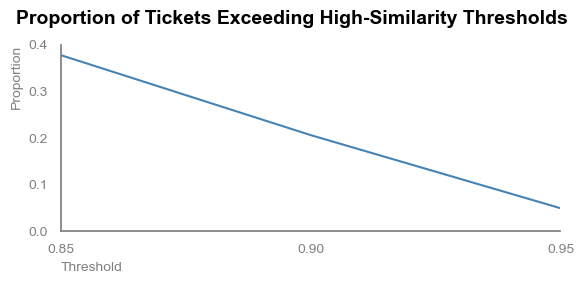

In [22]:
# Quantifying right-tail effect
right_tail_thresholds = [0.85, 0.9, 0.95]
right_tail_stats = []

for threshold in right_tail_thresholds:
    prop = (lemmatised_text_df["Lemma Max Similarity"] >= threshold).mean()
    right_tail_stats.append({"Threshold": threshold, "Proportion": prop})

right_tail_df = pd.DataFrame(right_tail_stats)
print("\nRight-tail similarity proportions:")
display(right_tail_df.style.format({"Threshold": "{:.2f}", "Proportion": "{:.3f}"}))

# Visualise the cumulative tail effect
# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(6, 3))

sns.lineplot(data=right_tail_df, x="Threshold", y="Proportion", color="steelblue")

# Set x-axis ticks to the discrete threshold values
ax.set_xticks(right_tail_thresholds)

# Remove horizontal padding so the line starts at the y-axis
ax.set_xlim(
    right_tail_df["Threshold"].min(),
    right_tail_df["Threshold"].max(),
)

# Set y-axis ticks to fit the proportion values
ax.set_yticks(np.linspace(0, 0.4, 5))

# Clean borders: remove top/right spines
sns.despine(ax=ax)

# Set labels and markers to grey for subtlety
ax.set_xlabel("Threshold", color="grey")
ax.set_ylabel("Proportion", color="grey")
ax.tick_params(colors="grey")

# Set the axis lines to grey for better aesthetics
ax.spines["left"].set_color("grey")
ax.spines["bottom"].set_color("grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_size(10)
ax.xaxis.label.set_size(10)
ax.tick_params(labelsize=10)

# Setting the axis allignment and position to the left for better aesthetics
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Title parameters
ax.set_title(
    "Proportion of Tickets Exceeding High-Similarity Thresholds",
    fontsize=14,
    fontweight="bold",
    color="black",
    pad=15,
    loc="left",
    x=-0.09,
)

plt.tight_layout()
plt.savefig(Config.RIGHT_TAIL_PATH, dpi=300, bbox_inches="tight")

print("\nProportion of tickets exceeding high-similarity thresholds:")
plt.show()

### Category recurrence

We grouped tickets by Type-Queue and calculated the recurrence rate for each: the proportion of tickets with a near-duplicate (≥0.85 similarity). This reveals which categories exhibit the highest thematic concentration and are therefore most actionable for automation or knowledge-base development.

In [23]:
# Creating a combined 'Type - Queue' column for grouping
lemmatised_text_df["Type - Queue"] = (
    lemmatised_text_df["Type"].astype(str)
    + " - "
    + lemmatised_text_df["Queue"].astype(str)
)

threshold = 0.85
records = []

# Loop to go through categories
for name, group in lemmatised_text_df.groupby("Type - Queue"):
    tfidf_sub = vec_lemma.transform(group["Lemmatised Text"])
    cos = cosine_similarity(tfidf_sub, dense_output=False)
    max_vals = [np.delete(cos[i].toarray(), i).max() for i in range(cos.shape[0])]
    recurrence = (np.array(max_vals) >= threshold).mean()
    records.append(
        {
            "Type": name.split(" - ")[0],
            "Queue": name.split(" - ")[1],
            "Group Size": len(group),
            "Recurrence Rate": recurrence,
        }
    )

# Create a DataFrame from the records
category_recurrence_df = pd.DataFrame(records)

# Calculating a combined impact score that weights recurrence rate and group size
category_recurrence_df["Impact Score"] = (
    # Highest reccurence rate show the topics which are most likely to have a solution in the knowledge base, so we weight this more heavily
    0.6
    * (
        category_recurrence_df["Recurrence Rate"]
        / category_recurrence_df["Recurrence Rate"].max()
    )
    +
    # We also want to prioritise categories with more records, as these will have a bigger impact if solved, but we weight this less heavily as large groups with low recurrence may not be as actionable
    0.4
    * (
        category_recurrence_df["Group Size"]
        / category_recurrence_df["Group Size"].max()
    )
)

# Rank by actionability score
category_recurrence_df = category_recurrence_df.sort_values(
    "Impact Score", ascending=False
)

category_recurrence_df["Actionable"] = np.where(
    category_recurrence_df["Impact Score"] > 0.5,
    "True",
    "False",
)


# Saving the category recurrence table to CSV
category_recurrence_df.to_csv(
    Config.CAT_RECURRENCE_CSV_PATH, index=False, encoding="utf-8"
)

# Showing the recurrence rates
display(
    category_recurrence_df.style.format(
        {"Recurrence Rate": "{:.3f}", "Group Size": "{:,}", "Impact Score": "{:.3f}"}
    )
)

,Type,Queue,Group Size,Recurrence Rate,Impact Score,Actionable
30,Request,Billing and Payments,657,0.610,0.671,True
19,Incident,Technical Support,"2,053",0.279,0.648,True
0,Change,Billing and Payments,86,0.674,0.617,True
31,Request,Customer Service,926,0.490,0.617,True
39,Request,Technical Support,815,0.501,0.604,True
33,Request,Human Resources,88,0.659,0.604,True
37,Request,Sales and Pre-Sales,209,0.555,0.535,True
35,Request,Product Support,580,0.467,0.529,True
2,Change,General Inquiry,57,0.579,0.526,True
15,Incident,Product Support,"1,181",0.312,0.507,True


### Category recurrence visuals

Finally, we plotted the recurrence rates by Type-Queue to visually identify which categories have the highest concentration of similar tickets. This helps to quickly spot where the most common issues are occurring and where targeted interventions could have the greatest impact.

In [24]:
# Apply Seaborn theme globally
sns.set_theme(style="white")

# Order queues by mean impact score (ascending so highest appears at top)
queue_order = (
    category_recurrence_df.groupby("Queue")["Impact Score"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)


Barplot of Impact Score by Queue and Type:


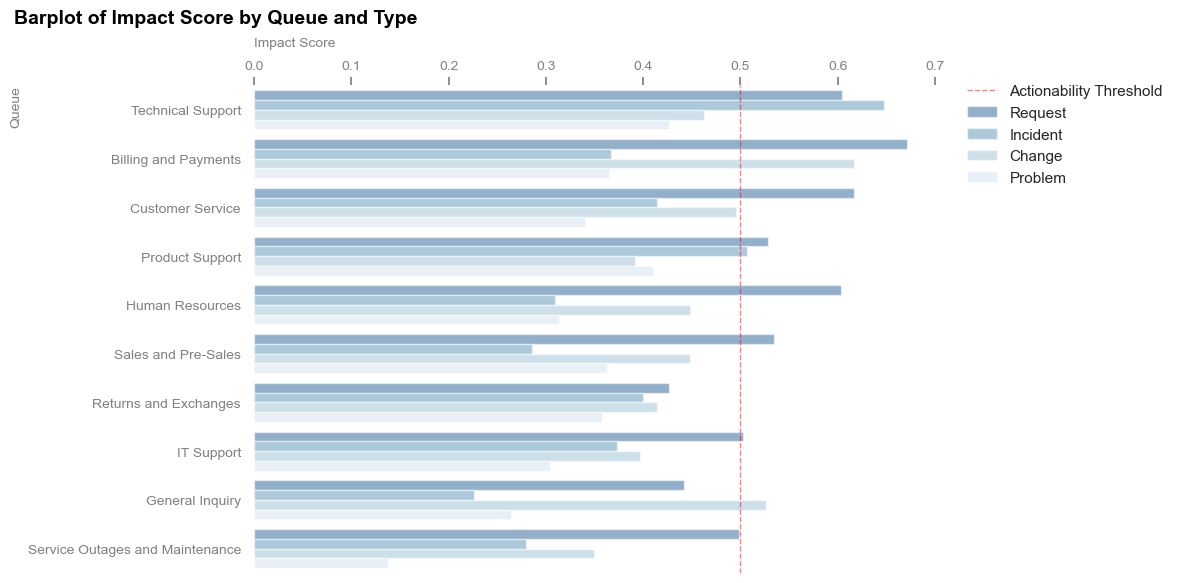

In [25]:
# Horizontal barplot of impact score by queue over type
# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(12, 6))

ax.axvline(
    x=0.5,
    color="red",
    linestyle="--",
    linewidth=1,
    alpha=0.5,
    label="Actionability Threshold",
)

# Plot higher-impact points in color by type
sns.barplot(
    data=category_recurrence_df,
    x="Impact Score",
    y="Queue",
    hue="Type",
    palette="Blues_r",
    alpha=0.5,
    order=queue_order,
)

# Clean borders by removing bottom/right spines
sns.despine(left=True, top=True, bottom=True, right=True)

# Set labels and markers to grey for subtlety
ax.set_xlabel("Impact Score", color="grey")
ax.set_ylabel("Queue", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_size(10)
ax.xaxis.label.set_size(10)
ax.tick_params(labelsize=10)

# X-axis on top for better readability
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1.3))
ax.xaxis.labelpad = 10  # Add padding to the x-axis label for better spacing

# Y-axis label alignment and position for better aesthetics
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Set title with font size 14 and grey color for subtlety
ax.set_title(
    "Barplot of Impact Score by Queue and Type",
    fontsize=14,
    fontweight="bold",
    color="black",
    pad=10,
    loc="left",
    x=-0.35,
)

# Move legend to the right side of the plot
ax.legend(bbox_to_anchor=(1.02, 1.03), loc="upper left", edgecolor="white")

plt.tight_layout()
plt.savefig(Config.IMPACT_BARPLOT_PATH, dpi=300, bbox_inches="tight")

print("\nBarplot of Impact Score by Queue and Type:")
plt.show()


Lineplot of Impact Score by Queue and Type:


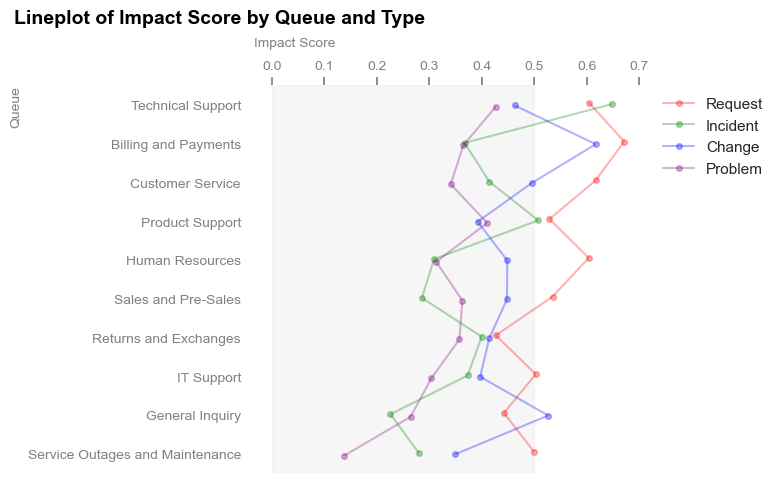

In [26]:
# Visualising the category recurrence rates with a line plot
# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(8, 5))

sns.pointplot(
    data=category_recurrence_df,
    y="Queue",
    x="Impact Score",
    hue="Type",
    order=queue_order,
    palette={
        "Request": "red",
        "Incident": "green",
        "Problem": "purple",
        "Change": "blue",
    },
    dodge=True,
    markers="o",
    markersize=4,
    linestyles="-",
    linewidth=1.5,
    alpha=0.3,
)

# Shade the area below impact score of 0.5
ax.axvspan(
    color="lightgrey",
    alpha=0.2,
    zorder=0,
    xmin=0,
    xmax=0.5,
)

# Clean borders by removing bottom/right spines
sns.despine(left=True, top=True, bottom=True, right=True)

ax.xaxis.set_ticks(np.arange(0, 0.71, 0.1))

# Set labels and markers to grey for subtlety
ax.set_xlabel("Impact Score", color="grey")
ax.set_ylabel("Queue", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_size(10)
ax.xaxis.label.set_size(10)
ax.tick_params(labelsize=10)

# X-axis on top for better readability
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.xaxis.labelpad = 10

# Y-axis label alignment and position for better aesthetics
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Set title
ax.set_title(
    "Lineplot of Impact Score by Queue and Type",
    fontsize=14,
    fontweight="bold",
    color="black",
    pad=10,
    loc="left",
    x=-0.62,
)

# Move legend to the right side of the plot
ax.legend(bbox_to_anchor=(1.02, 1.005), loc="upper left", edgecolor="white")

plt.tight_layout()
plt.savefig(Config.IMPACT_LINEPLOT_PATH, dpi=300, bbox_inches="tight")

print("\nLineplot of Impact Score by Queue and Type:")
plt.show()


Dotplot of Impact Score by Queue and Type:


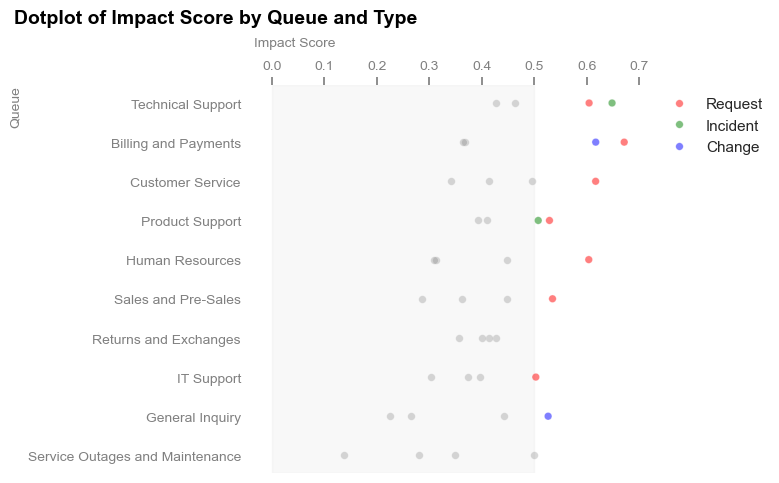

In [27]:
# Dotplot of impact score by queue and type
# Initialize the matplotlib figure
f, ax = plt.subplots(figsize=(8, 5))

# Anchor all queue positions in the desired order before plotting real data
sns.scatterplot(x=[0.0] * len(queue_order), y=queue_order, alpha=0, s=0)

# Plot lower-impact points in grey
sns.scatterplot(
    data=category_recurrence_df[category_recurrence_df["Actionable"] == "False"],
    x="Impact Score",
    y="Queue",
    color="grey",
    alpha=0.3,
    s=30,
    legend=False,
)

# Plot higher-impact points in color by type
sns.scatterplot(
    data=category_recurrence_df[category_recurrence_df["Actionable"] == "True"],
    x="Impact Score",
    y="Queue",
    hue="Type",
    palette={
        "Change": "blue",
        "Request": "red",
        "Incident": "green",
        "Problem": "purple",
    },
    alpha=0.5,
    s=30,
)

# Shade the area below impact score of 0.5
ax.axvspan(
    color="lightgrey",
    alpha=0.15,
    zorder=0,
    xmin=0,
    xmax=0.5,
)

# Clean borders by removing bottom/right spines
sns.despine(left=True, top=True, bottom=True, right=True)

ax.xaxis.set_ticks(np.arange(0, 0.71, 0.1))

# Set labels and markers to grey for subtlety
ax.set_xlabel("Impact Score", color="grey")
ax.set_ylabel("Queue", color="grey")
ax.tick_params(colors="grey")

# Set font size to 10 for better readability and align labels to the left
ax.yaxis.label.set_size(10)
ax.xaxis.label.set_size(10)
ax.tick_params(labelsize=10)

# X-axis on top for better readability
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.xaxis.label.set_horizontalalignment("left")
ax.xaxis.label.set_position((0, 1))
ax.xaxis.labelpad = 10

# Y-axis label alignment and position for better aesthetics
ax.yaxis.label.set_horizontalalignment("right")
ax.yaxis.label.set_position((0, 1))

# Set title
ax.set_title(
    "Dotplot of Impact Score by Queue and Type",
    fontsize=14,
    fontweight="bold",
    color="black",
    pad=10,
    loc="left",
    x=-0.62,
)

# Move legend to the right side of the plot
ax.legend(bbox_to_anchor=(1.02, 1.005), loc="upper left", edgecolor="white")

plt.tight_layout()
plt.savefig(Config.IMPACT_DOTPLOT_PATH, dpi=300, bbox_inches="tight")

print("\nDotplot of Impact Score by Queue and Type:")
plt.show()

### Findings

Key Metrics:

- 40% of tickets show ≥0.85 similarity to another ticket—indicating widespread thematic recurrence
- Request and Incident types dominate this recurrence (38–33%), followed by Changes (35%)
- Billing, Technical Support, and Product Support queues exhibit 24–32% repetition


Actionable Implications:

- High-recurrence ticket types (Requests, Incidents, Changes) are prime candidates for workflow automation and templated responses
- High-recurrence queues (Billing, Technical Support, Product Support) present opportunities for knowledge-base expansion, macro creation, or self-service features
- The balanced similarity distribution (0.3–0.7 peak) confirms healthy topic diversity—you're not over-clustering or over-simplifying

Using the full dataset (vs. a sample) naturally increased detection of recurring patterns, validating that these repeating themes reflect genuine operational bottlenecks rather than statistical artifacts.

TF-IDF analysis has identified where targeted investments in automation, documentation, and self-service tools would deliver the highest ROI by addressing concentrated workload clusters.
